# Survival

Survival plots display step-wise Kaplan-Meier curves; the at-risk table beneath the curve shows how many subjects remain under observation at selected time points.

## Kaplan-Meier curve with at-risk table

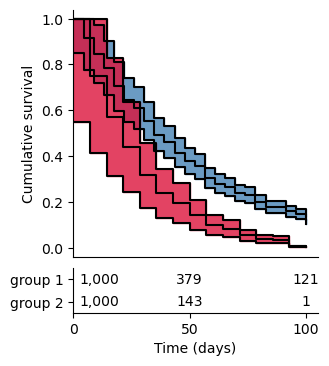

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

import plot_misc.example_data.examples as examples
import plot_misc.survival as pltm_surv

CMTOINCH = 1 / 2.54

data_dict, table = examples.load_survival_preprocessed()
# Creating a two row plot
f, axs = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8 * CMTOINCH, 10 * CMTOINCH),
    gridspec_kw={"height_ratios": [10, 1.8]},
    sharex=False,
)
plt.subplots_adjust(hspace=0.08)

# survival curves
for v in data_dict.values():
    _ = pltm_surv.plot_step_wise(
        v[0],
        estimate_col="survival_estimate",
        line_width=1.5,
        line_colour="black",
        lower_ci_col="lower_ci_95",
        upper_ci_col="upper_ci_95",
        line_width_ci=1.5,
        fill_colour=v[1],
        fill=True,
        ax=axs[0],
    )

# at-risk table
groups=['group 1', 'group 2']
_ = pltm_surv.plot_table(
    table,
    ax=axs[1],
    string_col=groups,
    yticklabel=groups,
    size_text=10,
    yloc=[0.25, 0.75],
    xticklabel=table['time'].to_list(),
    xtickloc=table['time'].to_list(),
    pad_first=11,
)

# formatting
xlims = (0, 105)
axs[0].margins(0.01, 0.04)
axs[0].set_xlim(xlims)
axs[1].set_xlim(xlims), 1

axs[0].spines[["top", "right"]].set_visible(False)
axs[0].set_ylabel("Cumulative survival")
axs[0].set_xticks([])
_ = axs[1].set_xlabel("Time (days)")